<a href="https://www.kaggle.com/code/allasamoilenko/notebook4a3d1a3cbe?scriptVersionId=227264972" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [10]:
import torch
from torch.utils.data import ConcatDataset
from torchvision import transforms, datasets
device = 'cuda' if torch.cuda.is_available() else 'cpu'

data_dir = '/kaggle/input/leukemia-classification/C-NMC_Leukemia/training_data'
dataset = datasets.ImageFolder(data_dir)

In [2]:
dataset.classes

['fold_0', 'fold_1', 'fold_2']

In [14]:
data_dir0 = '/kaggle/input/leukemia-classification/C-NMC_Leukemia/training_data/fold_0'
dataset0 = datasets.ImageFolder(data_dir0)
dataset0.classes
len(dataset0)

3527

In [7]:
data_dir1 = '/kaggle/input/leukemia-classification/C-NMC_Leukemia/training_data/fold_1'
dataset1 = datasets.ImageFolder(data_dir1)
dataset1.classes

['all', 'hem']

In [8]:
data_dir2 = '/kaggle/input/leukemia-classification/C-NMC_Leukemia/training_data/fold_2'
dataset2 = datasets.ImageFolder(data_dir2)
dataset2.classes

['all', 'hem']

In [15]:
dataset_base = ConcatDataset([dataset0, dataset1, dataset2])
dataset_base.classes = dataset2.classes
dataset_base.classes
len(dataset_base)

10661

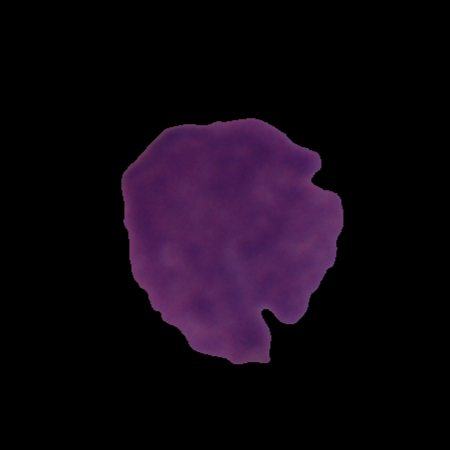

In [17]:
image, y = dataset_base[0] 
image

In [19]:
from torch.utils.data import random_split

torch.manual_seed(42)

dataset_train, dataset_test = random_split(dataset_base, (0.8, 0.2))

len(dataset_test)

2132

In [20]:
from torchvision import transforms

transformer_test = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

In [21]:
transformer_train = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ToTensor()
])

In [22]:
from torch.utils.data import Dataset

class TransformDataSet(Dataset):
    def __init__(self, data, transform):
        super().__init__()
        self.data = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self,n):
        image, key = self.data[n]
        image = self.transform(image)
        return image, key

dataset_train = TransformDataSet(dataset_train, transformer_train)
dataset_test = TransformDataSet(dataset_test, transformer_test)


In [23]:
dataset_train[0]

(tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]),
 1)

In [24]:
from torch.utils.data import DataLoader

train_loader = DataLoader(dataset_train, batch_size = 128, shuffle= True)
test_loader = DataLoader(dataset_test, batch_size = 128, shuffle= True)


In [25]:
for X_batch, y_batch in train_loader:
    
    break

In [28]:
X_batch.shape

torch.Size([128, 3, 256, 256])

In [30]:
y_batch

tensor([0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1,
        1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0,
        0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0,
        0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0,
        0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0,
        0, 0, 1, 0, 0, 1, 0, 0])